# Judge Comparisons - ROC-AUC Analysis

This notebook compares multiple judges against ROUGE-L continuous scores using ROC-AUC curves.
Each judge's binary classifications are evaluated against the continuous ROUGE-L scores from the reference collections.


In [1]:
import polars as pl
import matplotlib.pyplot as plt
from sklearn import metrics
import os

# Define paths
BINARY_COLLECTIONS_PATH = "binary_collections"
REFERENCE_COLLECTIONS_PATH = "reference_collections"

# Judge names mapping
JUDGES = {
    "naive": "Naive Judge",
    "pairwise_rag": "Pairwise RAG",
    "pairwise_zeroshot": "Pairwise ZeroShot",
    "voting_naive": "Voting Naive"
}

print("Environment setup complete.")

Environment setup complete.


## Analysis

This section evaluates the performance of four different judge implementations by comparing their binary classifications against continuous ROUGE-L scores. ROUGE-L (Recall-Oriented Understudy for Gisting Evaluation) is a standard metric for evaluating text generation quality based on the longest common subsequence between generated and reference text.

**Key Question**: Which judge best identifies high-quality context passages according to ROUGE-L scores?

**Evaluation Metric**: ROC-AUC (Area Under the Receiver Operating Characteristic Curve) measures the judge's ability to distinguish between high-quality (ROUGE-L > median) and low-quality passages. An AUC of 1.0 indicates perfect discrimination, while 0.5 represents random classification.



## Helper Function for ROC-AUC Computation

Define a function that properly handles data alignment (sorting and joining) before computing ROC-AUC scores.


In [2]:
def compute_roc_auc_with_alignment(judge_df, reference_df, reference_score_col="evaluation"):
    """
    Compute ROC-AUC with proper data alignment.
    
    Parameters:
    -----------
    judge_df : polars.DataFrame
        Binary judge classifications with columns: collection_idx, test_idx, evaluation
    reference_df : polars.DataFrame
        Continuous reference scores with columns: collection_idx, test_idx, {reference_score_col}
    reference_score_col : str, default "evaluation"
        Name of the column in reference_df containing the continuous scores
    
    Returns:
    --------
    tuple : (roc_auc_score, fpr, tpr, thresholds)
    """
    # Sort both dataframes
    judge_sorted = judge_df.sort("collection_idx", "test_idx")
    reference_sorted = reference_df.sort("collection_idx", "test_idx")
    
    # Join on collection_idx and test_idx (inner join to keep only aligned records)
    merged_df = judge_sorted.join(
        reference_sorted.select(["collection_idx", "test_idx", reference_score_col]).rename({reference_score_col: "ref_score"}),
        on=["collection_idx", "test_idx"],
        how="inner"
    )
    
    # Extract labels and scores
    y_true = merged_df["evaluation"].to_list()  # Binary judge labels
    y_scores = merged_df["ref_score"].to_list()  # Continuous reference scores
    
    # Calculate ROC-AUC
    fpr, tpr, thresholds = metrics.roc_curve(y_true, y_scores)
    roc_auc = metrics.auc(fpr, tpr)
    
    return roc_auc, fpr, tpr, thresholds

print("Helper function updated.")

Helper function updated.


In [3]:
def plot_judges_roc_auc(reference_df, reference_score_col, metric_name, judges_dict=JUDGES, binary_collections_path=BINARY_COLLECTIONS_PATH):
    """
    Create a 2x2 grid of ROC-AUC curves comparing judges against a continuous reference metric.
    
    Parameters:
    -----------
    reference_df : polars.DataFrame
        Continuous reference scores with columns: collection_idx, test_idx, and the reference_score_col
    reference_score_col : str
        Name of the column in reference_df containing the continuous scores
    metric_name : str
        Metric name for display (e.g., "ROUGE-L", "F1 Score")
    judges_dict : dict, default JUDGES
        Dictionary mapping judge keys to display names
    binary_collections_path : str, default BINARY_COLLECTIONS_PATH
        Path to the binary collections directory
    
    Returns:
    --------
    dict : auc_results (judge_key -> auc_score)
    dict : sample_sizes (judge_key -> count)
    """
    # Create 2x2 grid for ROC-AUC curves with improved styling
    fig, axes = plt.subplots(2, 2, figsize=(16, 13))
    fig.suptitle(f"Judge Performance: ROC-AUC Analysis vs {metric_name}", 
                 fontsize=18, fontweight='bold', y=0.995)
    
    # Flatten axes for easier indexing
    axes_flat = axes.flatten()
    
    # Define judge keys and their positions in the grid
    judge_keys = list(judges_dict.keys())
    auc_results = {}
    sample_sizes = {}
    
    # Color palette - use one consistent color for all judges
    curve_color = '#2E86AB'  # Professional blue
    random_color = '#A23B72'  # Purple for reference
    
    # Process each judge
    for idx, judge_key in enumerate(judge_keys):
        print(f"\n{'='*60}")
        print(f"Processing: {judges_dict[judge_key]}")
        print(f"{'='*60}")
        
        # Load judge's binary collection
        judge_path = os.path.join(binary_collections_path, judge_key, "train.feather")
        judge_df = pl.read_ipc(judge_path).filter(pl.col("evaluation").is_not_null())
        
        print(f"Judge data loaded: {judge_df.shape}")
        
        # Compute ROC-AUC with proper alignment
        roc_auc, fpr, tpr, thresholds = compute_roc_auc_with_alignment(judge_df, reference_df, reference_score_col)
        
        # Store results
        auc_results[judge_key] = roc_auc
        sample_sizes[judge_key] = len(judge_df)
        print(f"ROC-AUC Score: {roc_auc:.4f} | Sample Size: {sample_sizes[judge_key]:,}")
        
        # Plot on corresponding subplot
        ax = axes_flat[idx]
        
        # Plot ROC curve with enhanced styling
        ax.plot(fpr, tpr, color=curve_color, lw=3, label=f'ROC Curve (AUC = {roc_auc:.4f})', zorder=3)
        ax.fill_between(fpr, tpr, alpha=0.2, color=curve_color)
        
        # Plot random classifier reference line
        ax.plot([0, 1], [0, 1], color=random_color, lw=2, linestyle='--', 
                label='Random Classifier (AUC = 0.50)', alpha=0.7, zorder=2)
        
        # Styling improvements
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
        ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
        ax.set_title(f"{judges_dict[judge_key]}\n(n={sample_sizes[judge_key]:,})", 
                     fontsize=13, fontweight='bold', pad=15)
        
        # Add grid for better readability
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
        ax.set_axisbelow(True)
        
        # Legend with improved positioning
        ax.legend(loc="lower right", fontsize=11, framealpha=0.95, edgecolor='black', fancybox=True)
        
        # Set background color
        ax.set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{'='*60}")
    print(f"{metric_name} Analysis: AUC Scores Summary")
    print(f"{'='*60}")
    print(f"{'Judge':<25} {'AUC Score':>12} {'Sample Size':>15}")
    print(f"{'-'*52}")
    for judge_key, auc_score in sorted(auc_results.items(), key=lambda x: x[1], reverse=True):
        print(f"{judges_dict[judge_key]:<25} {auc_score:>12.4f} {sample_sizes[judge_key]:>15,}")
    print(f"{'-'*52}")
    
    # Calculate and display insights
    best_judge = max(auc_results.items(), key=lambda x: x[1])
    worst_judge = min(auc_results.items(), key=lambda x: x[1])
    avg_auc = sum(auc_results.values()) / len(auc_results)
    
    print(f"\nKey Findings:")
    print(f"  • Best Performer: {judges_dict[best_judge[0]]} (AUC = {best_judge[1]:.4f})")
    print(f"  • Lowest Performer: {judges_dict[worst_judge[0]]} (AUC = {worst_judge[1]:.4f})")
    print(f"  • Average AUC: {avg_auc:.4f}")
    print(f"  • Performance Gap: {best_judge[1] - worst_judge[1]:.4f}")
    print(f"{'='*60}")
    
    return auc_results, sample_sizes

print("Plotting function defined.")

Plotting function defined.


## ROUGE-L - ROC-AUC Curves

Create a 2x2 grid displaying ROC-AUC curves for each judge against ROUGE-L continuous scores.


In [ ]:
# Load ROUGE-L continuous collection and sort by collection_idx and test_idx
rougel_path = os.path.join(REFERENCE_COLLECTIONS_PATH, "llama_rougel.feather")
rougel_df = pl.read_ipc(rougel_path).sort("collection_idx", "test_idx")

print(f"ROUGE-L collection loaded: {rougel_df.shape}")
print(f"Columns: {rougel_df.columns}")
rougel_df.head()


Processing: Naive Judge
Judge data loaded: (6095180, 7)
ROC-AUC Score: 0.6722 | Sample Size: 6,095,180

Processing: Pairwise RAG
Judge data loaded: (6545543, 7)
ROC-AUC Score: 0.5562 | Sample Size: 6,545,543

Processing: Pairwise ZeroShot
Judge data loaded: (7075732, 7)
ROC-AUC Score: 0.5685 | Sample Size: 7,075,732

Processing: Voting Naive
Judge data loaded: (18885091, 7)
ROC-AUC Score: 0.6722 | Sample Size: 18,885,091


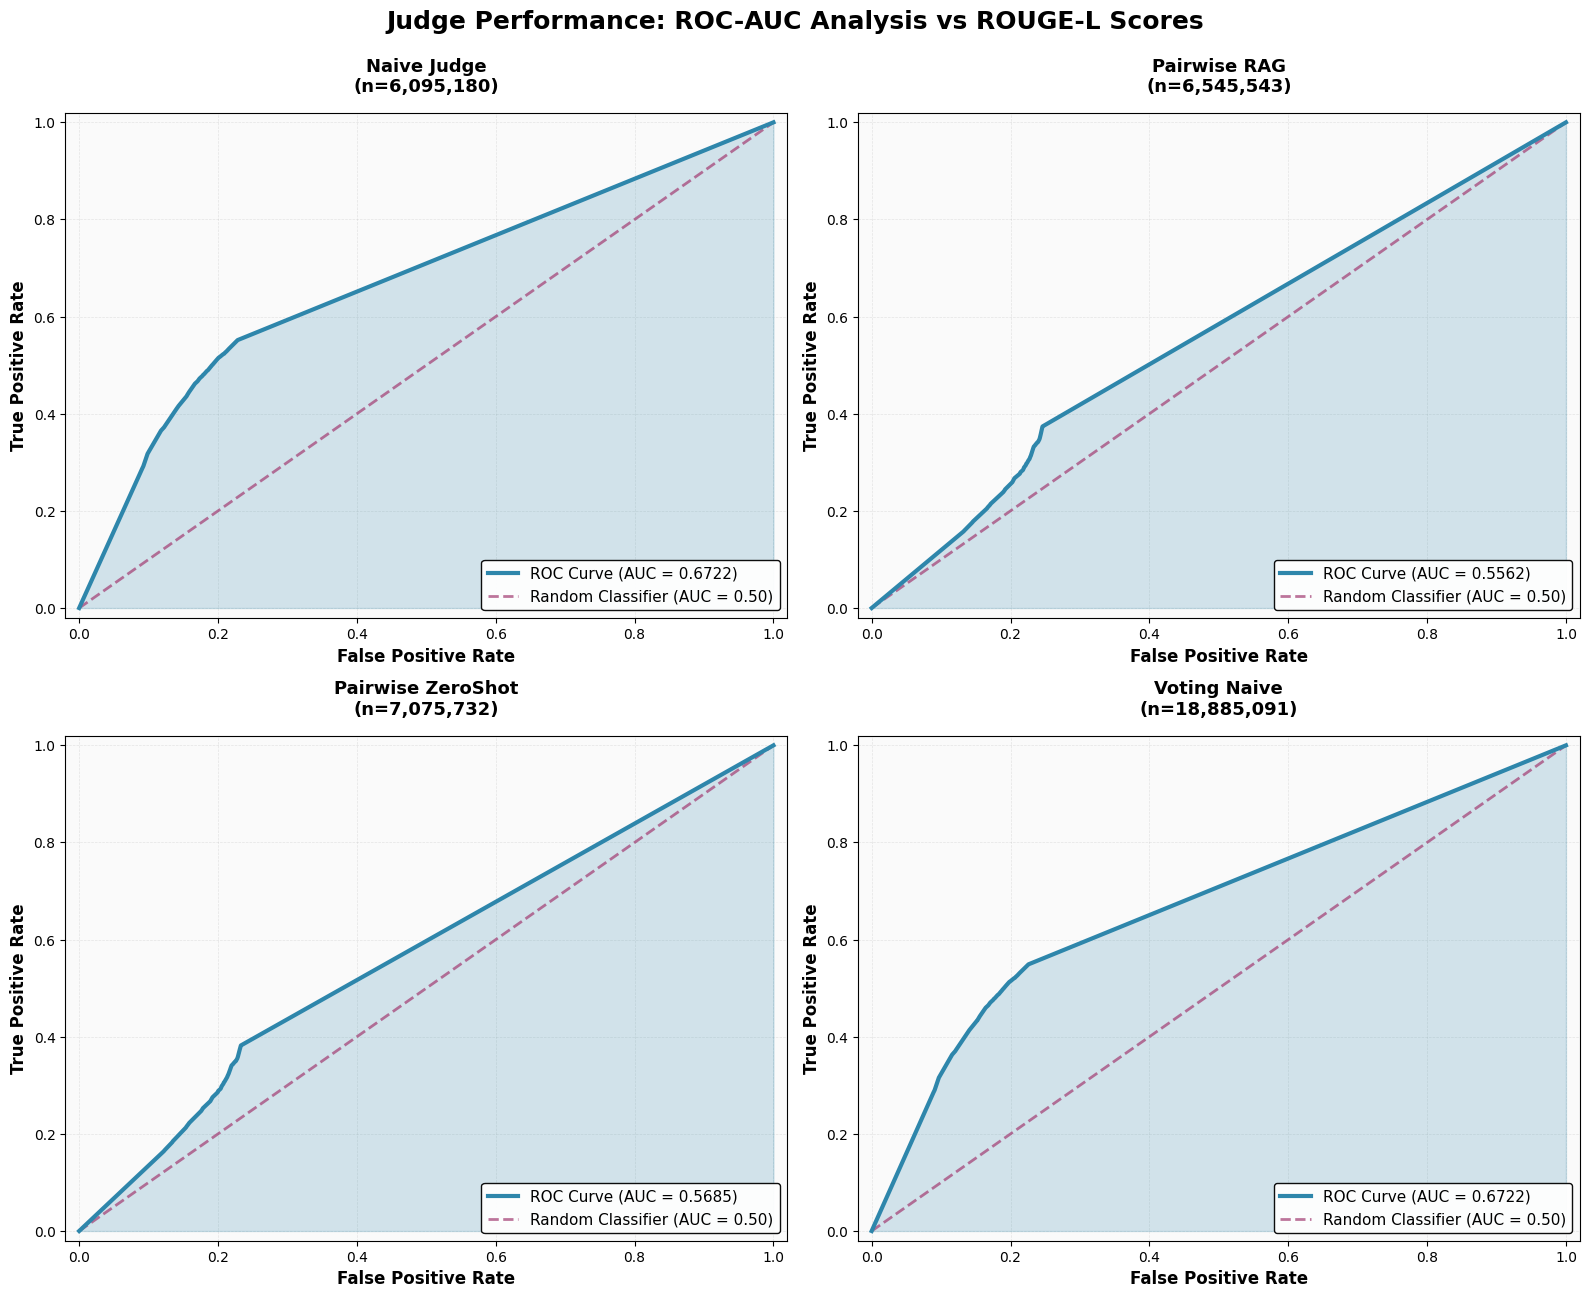


ROUGE-L Scores Analysis: AUC Scores Summary
Judge                        AUC Score     Sample Size
----------------------------------------------------
Naive Judge                     0.6722       6,095,180
Voting Naive                    0.6722      18,885,091
Pairwise ZeroShot               0.5685       7,075,732
Pairwise RAG                    0.5562       6,545,543
----------------------------------------------------

Key Findings:
  • Best Performer: Naive Judge (AUC = 0.6722)
  • Lowest Performer: Pairwise RAG (AUC = 0.5562)
  • Average AUC: 0.6172
  • Performance Gap: 0.1159


In [5]:
# Call the plotting function for ROUGE-L
auc_results, sample_sizes = plot_judges_roc_auc(
    reference_df=rougel_df,
    reference_score_col="evaluation",
    metric_name="ROUGE-L Scores"
)

## F1 Score Analysis

This section provides a complementary evaluation using F1 scores, which balance both precision and recall. While ROUGE-L emphasizes surface-level overlap, F1 provides a more nuanced measure of harmonic mean between precision and recall.

**Key Question**: Are judge rankings consistent across different metrics (ROUGE-L vs F1)?

**Rationale**: Comparing judges across multiple metrics provides robustness. If judges rank similarly on both metrics, we can be more confident in the findings. Divergent rankings may indicate that judges capture different aspects of context quality.



In [11]:
# Load F1 reference collection and sort by collection_idx and test_idx
f1_path = os.path.join(REFERENCE_COLLECTIONS_PATH, "llama_f1.feather")
f1_df = pl.read_ipc(f1_path).sort("collection_idx", "test_idx")

print(f"F1 collection loaded: {f1_df.shape}")
print(f"Columns: {f1_df.columns}")
f1_df.head()

F1 collection loaded: (7220000, 4)
Columns: ['collection_idx', 'test_idx', 'input', 'evaluation']


collection_idx,test_idx,input,evaluation
i64,i64,"array[i64, 100]",f64
250,0,"[0, 0, … 0]",0.8
250,1,"[0, 0, … 0]",0.571429
250,2,"[0, 0, … 0]",0.0
250,3,"[0, 0, … 0]",0.0
250,4,"[0, 0, … 0]",0.0


#### ROC-AUC Curves for Judges vs F1 Reference




Processing: Naive Judge
Judge data loaded: (6095180, 7)
ROC-AUC Score: 0.6686 | Sample Size: 6,095,180

Processing: Pairwise RAG
Judge data loaded: (6545543, 7)
ROC-AUC Score: 0.5526 | Sample Size: 6,545,543

Processing: Pairwise ZeroShot
Judge data loaded: (7075732, 7)
ROC-AUC Score: 0.5649 | Sample Size: 7,075,732

Processing: Voting Naive
Judge data loaded: (18885091, 7)


KeyboardInterrupt: 

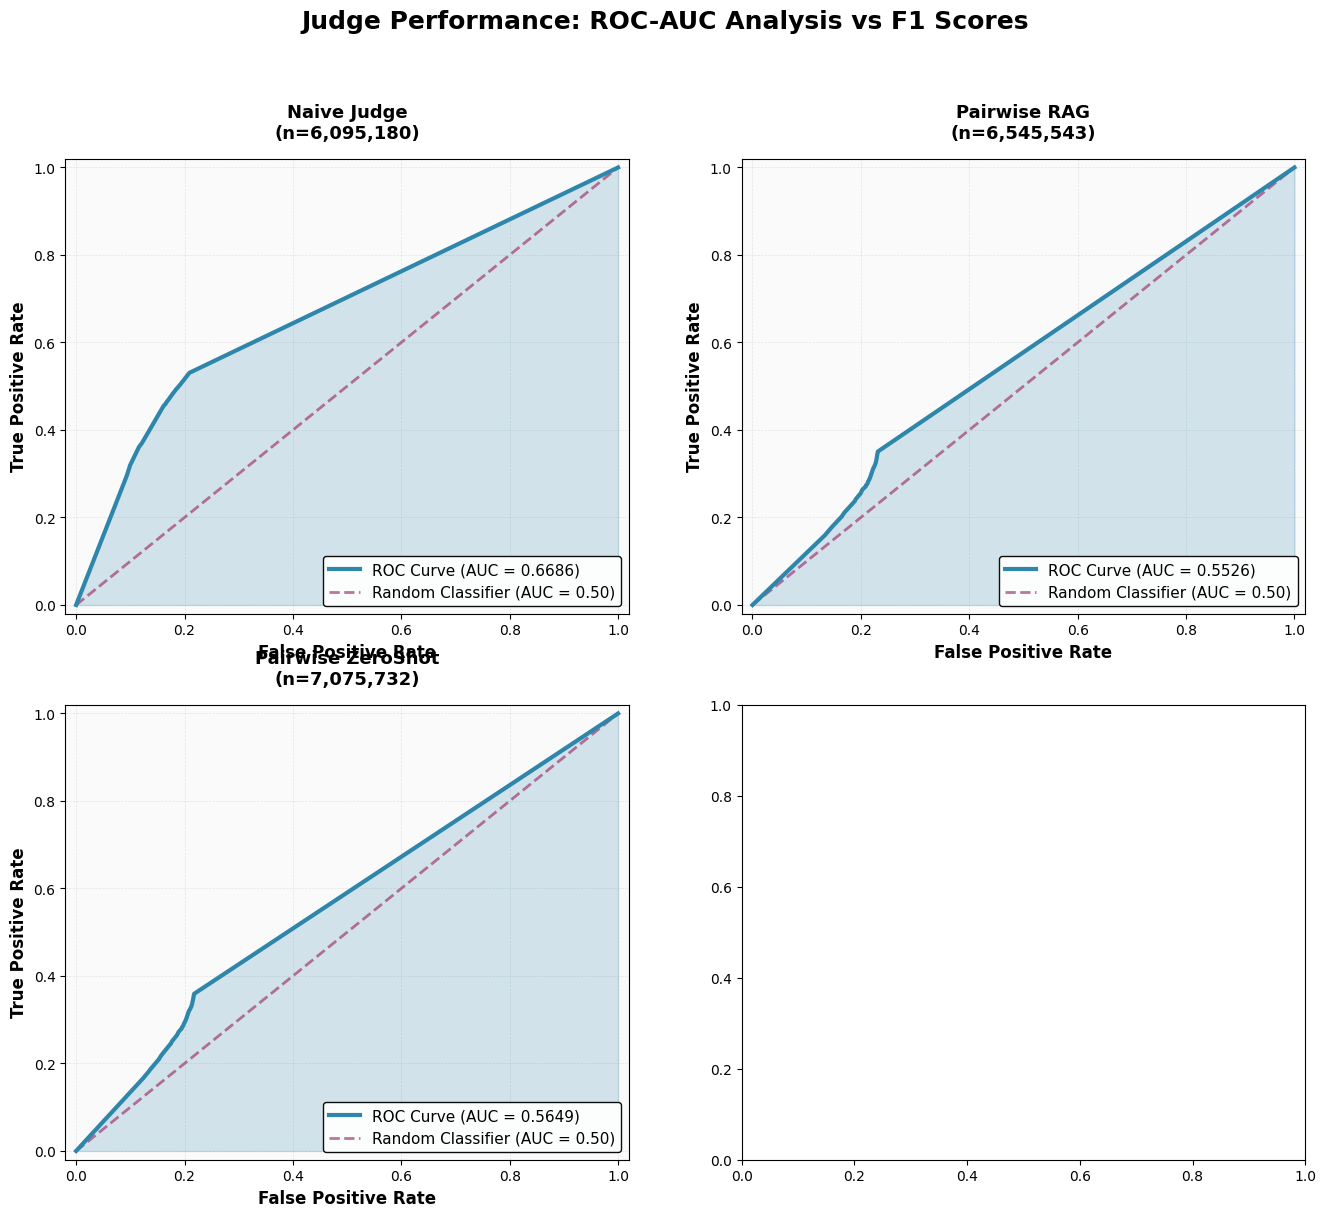

In [12]:
# Call the plotting function for F1
f1_auc_results, f1_sample_sizes = plot_judges_roc_auc(
    reference_df=f1_df,
    reference_score_col="evaluation",
    metric_name="F1 Scores"
)

## EM Score Analysis

In [4]:
# Load EM reference collection and sort by collection_idx and test_idx
em_path = os.path.join(REFERENCE_COLLECTIONS_PATH, "llama_em.feather")
em_df = pl.read_ipc(em_path).sort("collection_idx", "test_idx")

print(f"EM collection loaded: {em_df.shape}")
print(f"Columns: {em_df.columns}")
em_df.head()

EM collection loaded: (7220000, 4)
Columns: ['collection_idx', 'test_idx', 'input', 'evaluation']


collection_idx,test_idx,input,evaluation
i64,i64,"array[i64, 100]",f64
250,0,"[0, 0, … 0]",0.0
250,1,"[0, 0, … 0]",0.0
250,2,"[0, 0, … 0]",0.0
250,3,"[0, 0, … 0]",0.0
250,4,"[0, 0, … 0]",0.0



Processing: Naive Judge
Judge data loaded: (6095180, 7)
ROC-AUC Score: 0.5988 | Sample Size: 6,095,180

Processing: Pairwise RAG
Judge data loaded: (6545543, 7)
ROC-AUC Score: 0.5127 | Sample Size: 6,545,543

Processing: Pairwise ZeroShot
Judge data loaded: (7075732, 7)
ROC-AUC Score: 0.5211 | Sample Size: 7,075,732

Processing: Voting Naive
Judge data loaded: (18885091, 7)
ROC-AUC Score: 0.5989 | Sample Size: 18,885,091


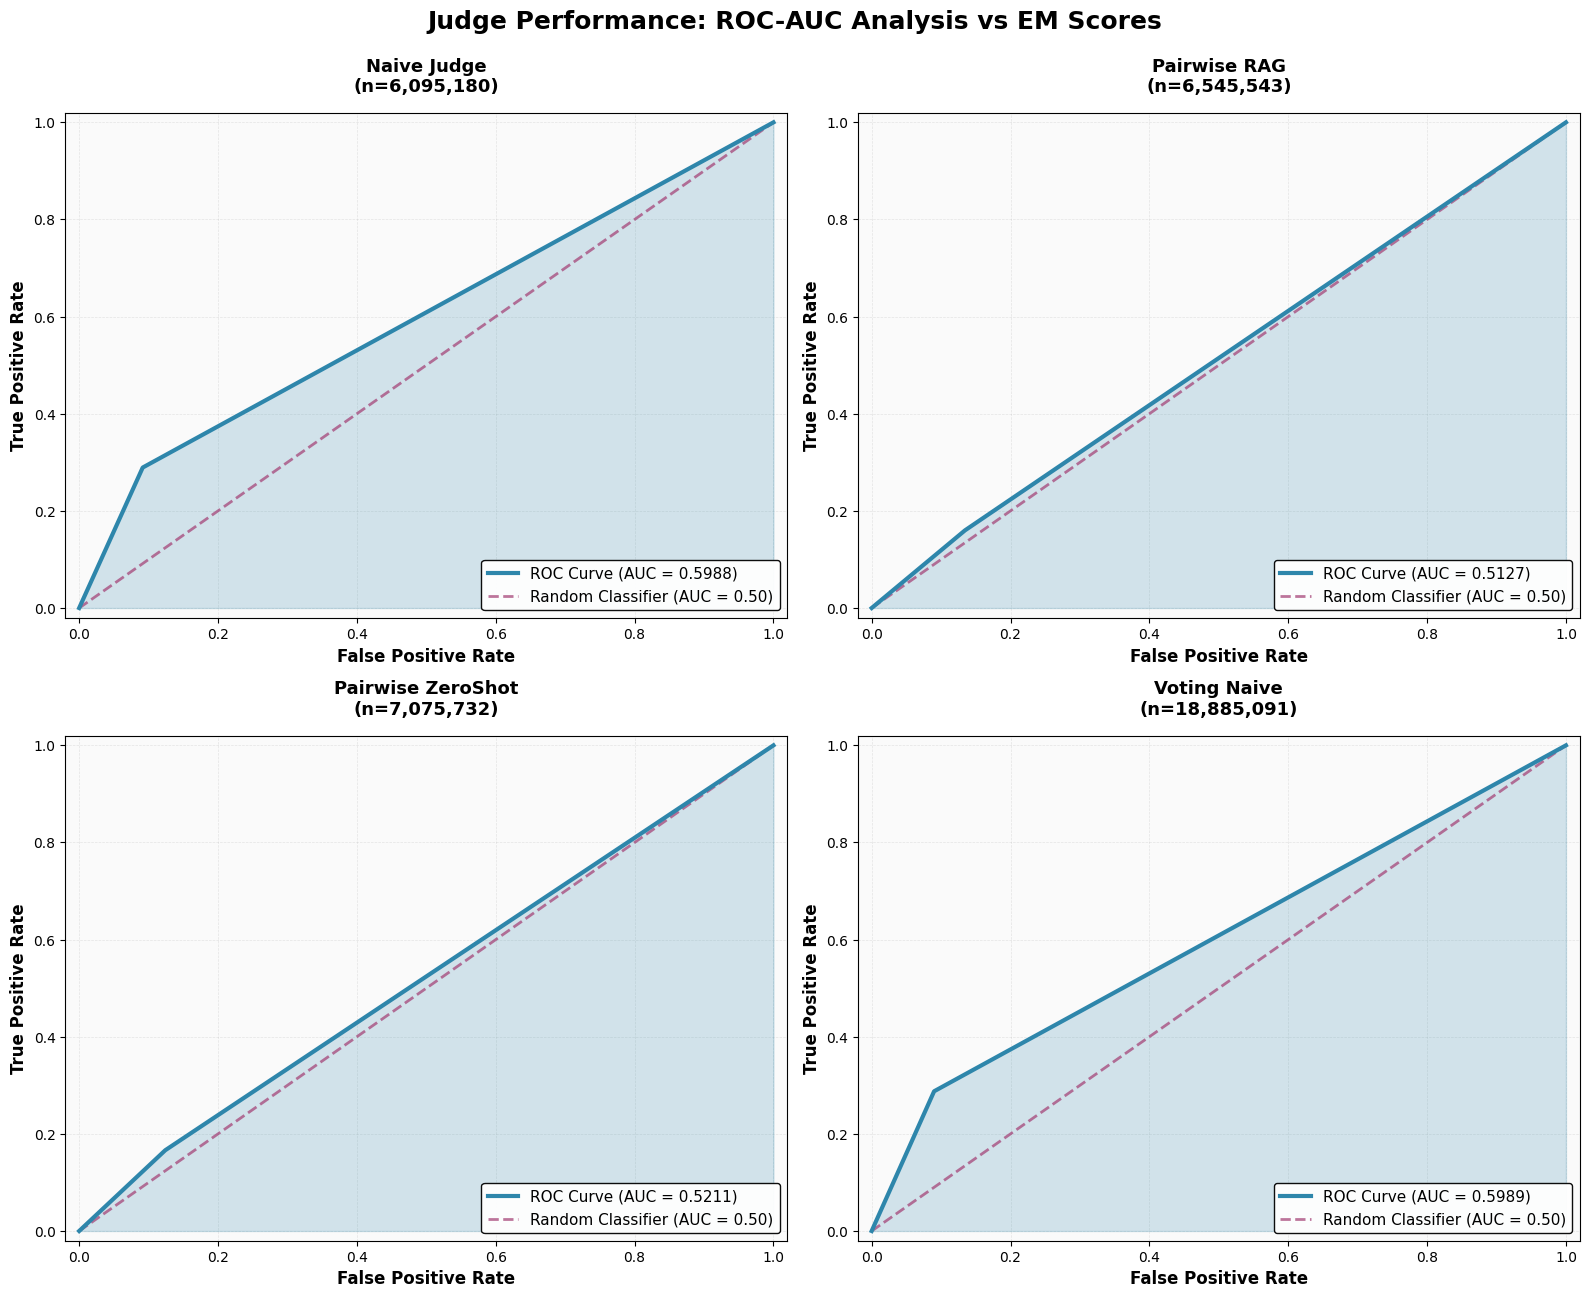


EM Scores Analysis: AUC Scores Summary
Judge                        AUC Score     Sample Size
----------------------------------------------------
Voting Naive                    0.5989      18,885,091
Naive Judge                     0.5988       6,095,180
Pairwise ZeroShot               0.5211       7,075,732
Pairwise RAG                    0.5127       6,545,543
----------------------------------------------------

Key Findings:
  • Best Performer: Voting Naive (AUC = 0.5989)
  • Lowest Performer: Pairwise RAG (AUC = 0.5127)
  • Average AUC: 0.5579
  • Performance Gap: 0.0861


In [5]:
em_auc_results, em_sample_sizes = plot_judges_roc_auc(
    reference_df=em_df,
    reference_score_col="evaluation",
    metric_name="EM Scores"
)
del em_df  # Free memory